# **Pydantic**
## Pydantic in LangGraph

**Pydantic** is a data validation library used to define structured schemas with type checking. In LangGraph, it helps create robust state schemas by validating inputs, enforcing data types, providing default values, and preventing invalid state updates. This makes graph workflows more reliable, maintainable, and easier to debug.

**Why use Pydantic?**

* Automatic data validation
* Type safety
* Default values and constraints
* Better error handling
* Cleaner and more maintainable state management

**Key Idea:** Pydantic = Structured and validated state for reliable graph execution.

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os
load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("Google API Key is set.")
else:
    raise ValueError("Google API Key is not set.")

Google API Key is set.


In [2]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

### **Pydantic Schema**

In [ ]:
# You should always devide the work you want to  get it done from the llm  in small small chunks because it performs the task better 
# when you provide the only one task at a time.

from pydantic import BaseModel, Field 

class graph_schema(BaseModel):

    topic: str = Field(description="The topic of the graph")
    post: str = Field(description="The LinkedIn post content")
    curated_post: str = Field(description="The curated LinkedIn post content")

# just to look how our object will be
demo_obj = graph_schema(
    topic="The importance of data privacy in the digital age",
    post="Data privacy is crucial in today's digital world. With the increasing amount of personal information being shared online, it's important to understand how to protect your data and maintain your privacy.",
    curated_post="In the digital age, data privacy is more important than ever. With the"
)
print(demo_obj)

topic='The importance of data privacy in the digital age' post="Data privacy is crucial in today's digital world. With the increasing amount of personal information being shared online, it's important to understand how to protect your data and maintain your privacy." curated_post='In the digital age, data privacy is more important than ever. With the'


### **Create the Nodes**

**Note** - In Langchain the output of one node is the input of the next node but in LangGraph its not the case.
**How it works** - first nodes updates the state(schema) and second node utilizes the updated state schema.

```text
Initial State
      │
      ▼
┌─────────┐      Updated State      ┌─────────┐      Updated State      ┌─────────┐
│ Node 1  │ ─────────────────────►  │ Node 2  │ ─────────────────────►  │ Node 3  │
└─────────┘                         └─────────┘                         └─────────┘
                                                                             │
                                                                             ▼
                                                                        Final State
```

**Actual LangGraph Flow**

```text
Shared State
     │
     ▼
┌─────────┐     updates     ┌─────────┐     updates     ┌─────────┐
│ Node 1  │ ─────────────►  │ Node 2  │ ─────────────►  │ Node 3  │
└─────────┘                 └─────────┘                 └─────────┘
      │                          │                             │
      └──────────>Reads & Updates Same Shared State <──────────┘
```

**Key Idea:** Nodes do not pass outputs directly. Each node reads the current shared state, updates it and the next node receives the updated state.


In [7]:
# 1st Node  to create the post using LLM
def create_post(state: graph_schema) -> graph_schema:
    
    # Convert the Pydantic model to a dictionary. if you dont want to convert it into dict. then simply do topic = state.topic
    state = state.model_dump()

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a LinkedIn post
    post = llm.invoke(f"Write a LinkedIn post about {topic}").content

    # Update the state with the generated post
    state['post'] = post

    return state

#  2nd Node to curet the post 
def curate_post(state: graph_schema) -> graph_schema:

    # Convert the Pydantic model to a dictionary
    state = state.model_dump()

    # Extract the post from the state
    post = state['post']

    # Passing the post to the LLM to curate it
    curated_post = llm.invoke(f"Curate the following LinkedIn post with GenZ tone: {post}").content


    # Update the state with the curated post
    state['curated_post'] = curated_post

    return state

### **Create the Graph**

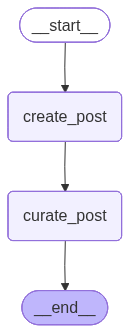

In [11]:
from langgraph.graph import StateGraph, START, END

# Define the graph
graph = StateGraph(graph_schema)

# Add the two created nodes to the graph
# add_node(node_name, node_function)
# First parameter: Unique node name (string identifier)
# Second parameter: Function that will execute when this node is reached
graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)


# Node names are used while connecting nodes with edges
# Start edge will be added to "create_post" node
# START -> create_post
graph.add_edge(START, "create_post")

# This edge will connect "create_post" and "curet_post" node
# create_post -> curet_post
graph.add_edge("create_post", "curate_post")

# This edge will start from "curet_post" node 
# curet_post -> END
graph.add_edge("curate_post", END)

# Compile the graph into an executable workflow
# Validates nodes, edges, and state transitions
# Returns a runnable graph object that can process inputs
pydantic_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(pydantic_graph.get_graph().draw_mermaid_png())

In [ ]:
pydantic_graph.invoke(
    {"topic": "The importance of data privacy in the digital age",
     "post": "",
     "curated_post": ""}
)